In [ ]:
# Imports
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional, List
import numpy as np

In [564]:
class DataHandler:
    def __init__(self, ticker: str, start: str, end: str):
        self.ticker = ticker
        self.start = start
        self.end = end
        self.data = None

    def download_data(self) -> pd.DataFrame:
        self.data = yf.download(self.ticker, start=self.start, end=self.end)
        if self.data.empty:
            raise ValueError(f"No data found for {self.ticker}")
        if isinstance(self.data.columns, pd.MultiIndex):
            self.data.columns = [col[0] for col in self.data.columns]
        return self.data

    def get_data(self, columns: Optional[List[str]] = None) -> pd.DataFrame:
        if self.data is None:
            raise ValueError("Data not downloaded yet.")
        if columns:
            return self.data[columns]
        return self.data


In [565]:
import matplotlib.dates as mdates
class Plotter:
    def __init__(self, data: pd.DataFrame):
        self.data = data


    def plot_price(self, title: str = "Price Chart", ticker: str = "Ticker", volume_width: int = 1):
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, height_ratios=[3, 1])

        # X-axis: convert dates to numerical values
        x_vals = mdates.date2num(self.data.index)

        # Top chart: Close price + filled area
        close_price = self.data['Close'].values.ravel()
        ax1.plot(self.data.index, close_price, label='Close Price', color='tab:blue')
        ax1.fill_between(self.data.index, close_price, color='tab:blue', alpha=0.1)  # Area under line
        ax1.set_title(f"{title} - {ticker}")
        ax1.set_ylabel("Price")
        ax1.legend()
        ax1.grid(True)

        # --- Bottom chart: Adjusted volume bars ---
        df = self.data.copy().reset_index()
        df.rename(columns={df.columns[0]: 'Date'}, inplace=True)
    
        # Group every N rows (N = volume_width)
        group_indices = df.index // volume_width
        grouped = df.groupby(group_indices).agg({
            'Date': lambda x: x.iloc[len(x) // 2],  # use middle date of the group for centering
            'Open': 'first',
            'Close': 'last',
            'Volume': 'sum'
        })
    
        # Bar properties
        x_vals = mdates.date2num(grouped['Date'])
        volume = grouped['Volume'].to_numpy()
        open_ = grouped['Open'].to_numpy()
        close = grouped['Close'].to_numpy()
    
        # Color logic
        colors = np.where(close > open_, 'green', np.where(close < open_, 'red', 'gray'))
    
        # Compute dynamic bar width based on actual time gaps
        if len(x_vals) > 1:
            avg_gap = np.mean(np.diff(x_vals))  # average days between bar centers
        else:
            avg_gap = volume_width  # fallback for single bar
        
        # Plot volume bars with dynamic width to eliminate gaps
        ax2.bar(x_vals, volume, color=colors, width=volume_width, align='center')

        ax2.set_ylabel("Volume")
        ax2.grid(True)
    
        # Format x-axis
        ax2.xaxis_date()
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        plt.xlabel("Date")
        plt.tight_layout()
        plt.show()

    def plot_signals(
        self,
        signal_obj,
        title: str = "Signal Plot",
        highlight: bool = True,
        plot_indicators: bool = False
    ):

        if not hasattr(signal_obj, 'signals'):
            raise TypeError("signal_obj must implement a .signals() method.")

        # Pull signals
        signals = signal_obj.signals()
        df = self.data.copy()
        df['Signal'] = signals['Signal']

        plt.figure(figsize=(14, 6))
        plt.plot(df['Close'], label='Close Price', alpha=0.8)

        # Optional: plot SMA or other overlays
        if plot_indicators and hasattr(signal_obj, 'get_indicators_to_plot'):
            indicators = signal_obj.get_indicators_to_plot()
            for label, col in indicators.items():
                indicator_data = getattr(signal_obj, 'data', self.data)
                if col in indicator_data.columns:
                    plt.plot(indicator_data[col], label=label, linestyle='--', alpha=0.7)


        # Optional: highlight long/short zones
        if highlight:
            in_position = False
            entry_idx = None
            current_signal = None

            for i in range(1, len(df)):
                prev = df['Signal'].iloc[i - 1]
                curr = df['Signal'].iloc[i]

                if not in_position and curr != 0:
                    entry_idx = df.index[i]
                    current_signal = curr
                    in_position = True

                elif in_position and (curr != current_signal or curr == 0):
                    exit_idx = df.index[i]
                    color = 'green' if current_signal == 1 else 'red'
                    plt.axvspan(entry_idx, exit_idx, color=color, alpha=0.2)
                    in_position = False
                    current_signal = None

            if in_position:
                color = 'green' if current_signal == 1 else 'red'
                plt.axvspan(entry_idx, df.index[-1], color=color, alpha=0.2)

        plt.title(title)
        plt.xlabel("Date")
        plt.ylabel("Price")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


[*********************100%***********************]  1 of 1 completed


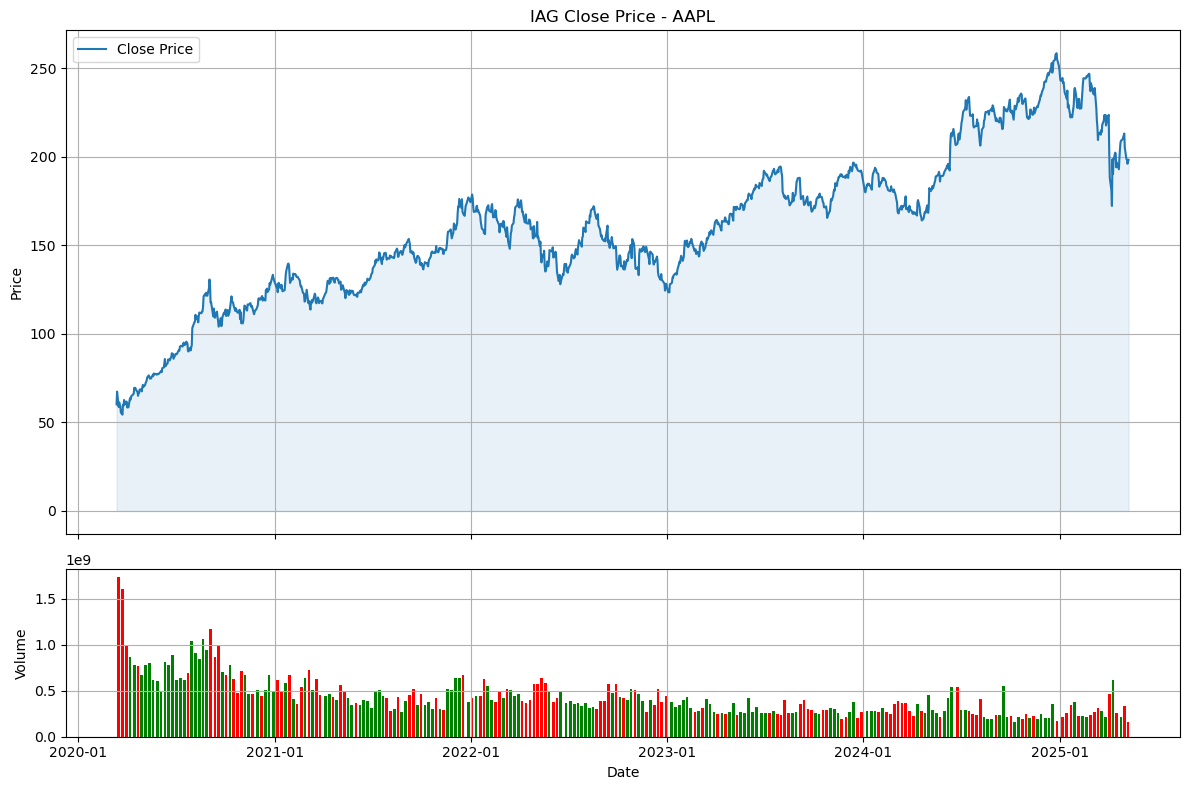

In [566]:
# Plotting apple ticker example
data_handler = DataHandler(ticker="AAPL", start="2020-03-12", end="2025-05-12") #year-day-month IAG.L
data = data_handler.download_data()

plotter = Plotter(data)
plotter.plot_price(title="IAG Close Price", ticker="AAPL", volume_width=5) #5 and 7 approximate yahoo finance 

In [567]:
# My first indicator
class SMAIndicator:
    def __init__(self, data: pd.DataFrame, short_window: int = 20, long_window: int = 50):
        self.data = data.copy()
        self.short_window = short_window
        self.long_window = long_window
        self._computed = False
        self.signals_ = pd.DataFrame(index=self.data.index)

    def compute(self):
        if not self._computed:
            self.data['SMA_Short'] = self.data['Close'].rolling(window=self.short_window).mean()
            self.data['SMA_Long'] = self.data['Close'].rolling(window=self.long_window).mean()

            signal_array = np.where(
                self.data['SMA_Short'] > self.data['SMA_Long'], 1, -1
            )

            self.signals_['Signal'] = signal_array
            self._computed = True

    def signals(self) -> pd.DataFrame:
        self.compute()
        return self.signals_

    def get_indicators_to_plot(self) -> dict:
        return {
            f"SMA ({self.short_window})": "SMA_Short",
            f"SMA ({self.long_window})": "SMA_Long"
        }


In [568]:
# My first strategy
class SMACrossoverStrategy:
    def __init__(self, indicator: SMAIndicator):
        self.indicator = indicator
        self.data = indicator.data.copy()  
        self.signals_ = pd.DataFrame(index=self.data.index)
        self._computed = False

    def compute(self):
        if not self._computed:
            # Get signals from the indicator
            base_signals = self.indicator.signals().copy()
            
            self.signals_ = base_signals
            base_signals['Signal'] = base_signals['Signal'].apply(lambda x: 1 if x == 1 else 0)
            self._computed = True

    def signals(self) -> pd.DataFrame:
        self.compute()
        return self.signals_

    def get_indicators_to_plot(self) -> dict:
        return self.indicator.get_indicators_to_plot()


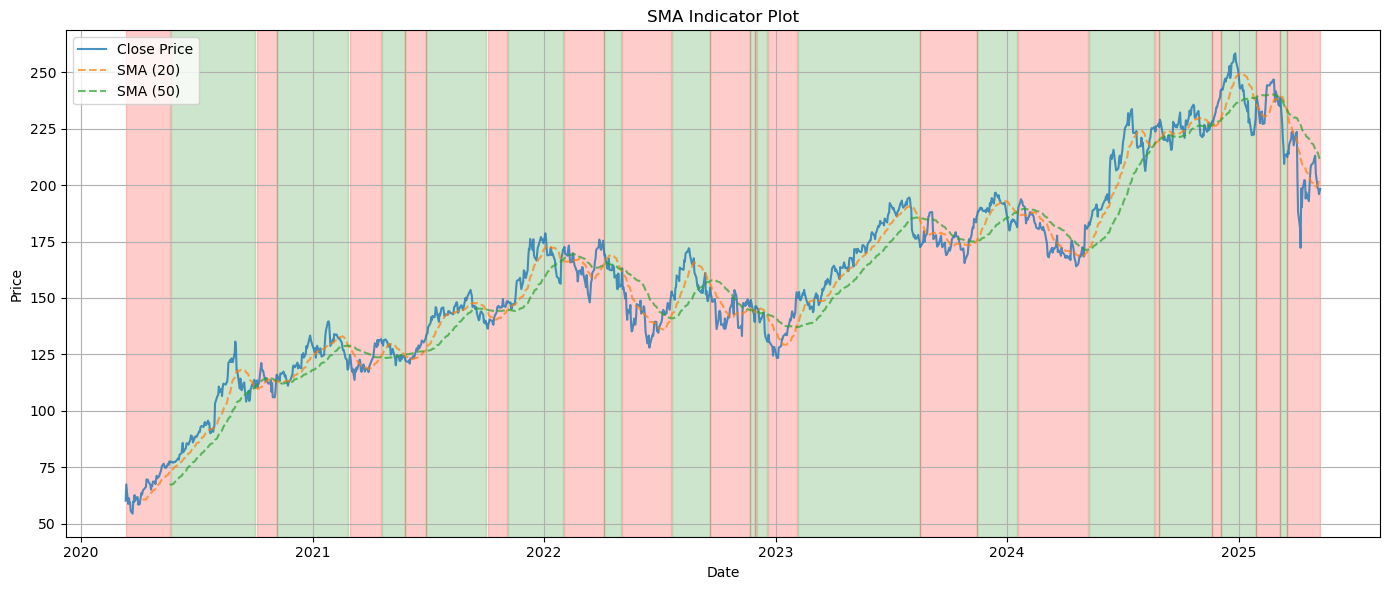

In [569]:
signal_obj=SMAIndicator(data, short_window=20, long_window=50)

plotter = Plotter(data)
plotter.plot_signals(signal_obj, title="SMA Indicator Plot", highlight = True, plot_indicators = True)

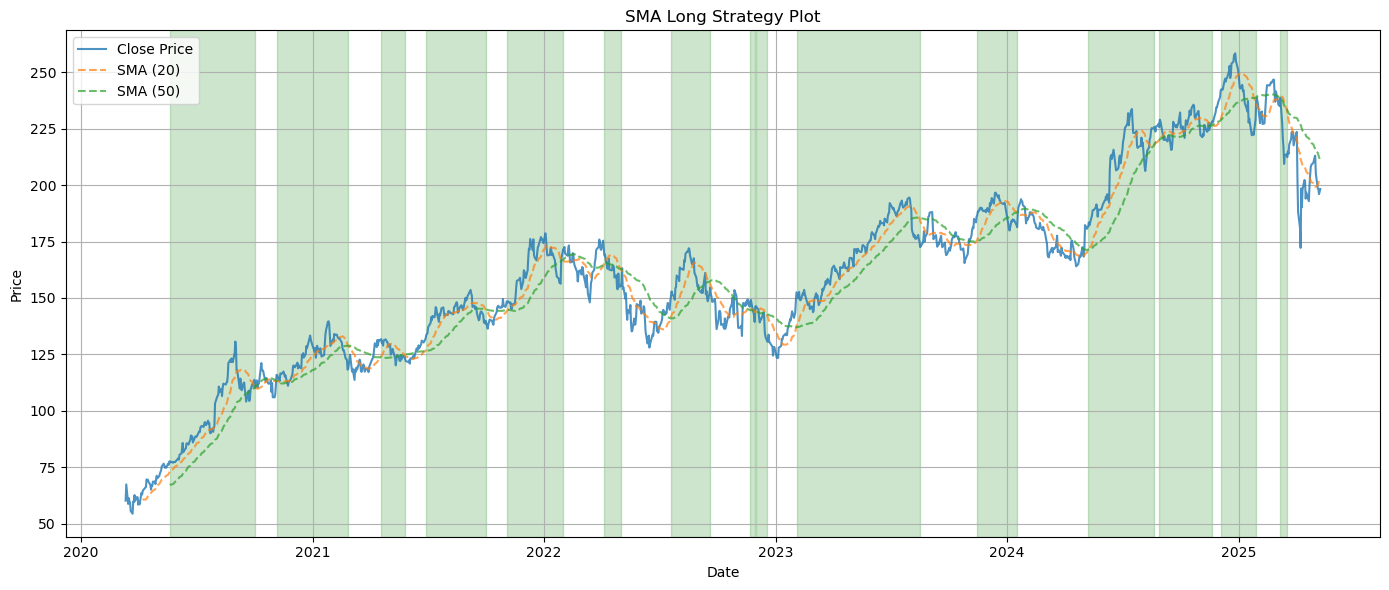

In [570]:
signal_obj2=SMACrossoverStrategy(signal_obj)

plotter = Plotter(data)
plotter.plot_signals(signal_obj2, title="SMA Long Strategy Plot", highlight = True, plot_indicators = True)

In [571]:
class Backtester:
    def __init__(self, data: pd.DataFrame, signals: pd.Series, initial_cash: float = 100.0, transaction_cost: float = 0.0):
        self.data = data.copy()
        self.signals = signals
        self.initial_cash = initial_cash
        self.transaction_cost = transaction_cost
        self.results = None
        self.trades = []

    def run(self):
        df = self.data.copy()
        df['Signal'] = self.signals
        df['Position'] = df['Signal'].shift(1).fillna(0)
        df['Market Return'] = df['Close'].pct_change().fillna(0)
        df['Strategy Return'] = df['Position'] * df['Market Return']
        df['Strategy Return'] -= np.abs(df['Position'].diff().fillna(0)) * self.transaction_cost

        df['Equity Curve'] = (1 + df['Strategy Return']).cumprod() * self.initial_cash
        self.results = df

        self._generate_trade_log()
        return df

    def _generate_trade_log(self):
        df = self.results
        in_position = False
        entry_price = None
        entry_index = None
        entry_signal = None
    
        for i in range(1, len(df)):
            curr_signal = df['Signal'].iloc[i]
            prev_signal = df['Signal'].iloc[i - 1]
    
            # Entry
            if not in_position and curr_signal in [1, -1]:
                in_position = True
                entry_price = float(df['Close'].iloc[i])
                entry_index = df.index[i]
                entry_signal = curr_signal  # 1 = long, -1 = short
    
            # Exit
            elif in_position and (curr_signal == 0 or curr_signal != entry_signal):
                exit_price = float(df['Close'].iloc[i])
                exit_index = df.index[i]
    
                if entry_signal == 1:  # Long trade
                    pnl = (exit_price - entry_price) / entry_price
                    trade_type = 'Long'
                else:  # Short trade
                    pnl = (entry_price - exit_price) / entry_price
                    trade_type = 'Short'
    
                self.trades.append({
                    'Type': trade_type,
                    'Entry Date': entry_index,
                    'Exit Date': exit_index,
                    'Entry Price': entry_price,
                    'Exit Price': exit_price,
                    'PnL (%)': float(pnl) * 100
                })
    
                in_position = False
                entry_price = None
                entry_index = None
                entry_signal = None
    
        # If still in a position at the end, close it with last available price
        if in_position:
            exit_price = float(df['Close'].iloc[-1])
            exit_index = df.index[-1]
    
            if entry_signal == 1:
                pnl = (exit_price - entry_price) / entry_price
                trade_type = 'Long'
            else:
                pnl = (entry_price - exit_price) / entry_price
                trade_type = 'Short'
    
            self.trades.append({
                'Type': trade_type,
                'Entry Date': entry_index,
                'Exit Date': exit_index,
                'Entry Price': entry_price,
                'Exit Price': exit_price,
                'PnL (%)': float(pnl) * 100
            })

    def get_performance(self):
        if self.results is None:
            raise ValueError("Run the backtest first.")

        equity = self.results['Equity Curve']
        returns = self.results['Strategy Return']
        market_returns = self.results['Market Return']
        n_days = len(self.results)
        n_years = n_days / 252

        total_return = equity.iloc[-1] - self.initial_cash
        annual_return = (equity.iloc[-1] / self.initial_cash) ** (1 / n_years) - 1 if n_years > 0 else np.nan

        daily_volatility = returns.std()
        annual_volatility = daily_volatility * np.sqrt(252)

        sharpe = returns.mean() / daily_volatility * np.sqrt(252) if daily_volatility != 0 else np.nan

        downside = returns[returns < 0].std()
        sortino = returns.mean() / downside * np.sqrt(252) if downside != 0 else np.nan

        roll_max = equity.cummax()
        drawdown = (equity - roll_max) / roll_max
        max_drawdown = drawdown.min()

        exposure = (self.results['Position'] != 0).mean()

        if len(market_returns) > 1:
            cov_matrix = np.cov(returns, market_returns)
            beta = cov_matrix[0, 1] / cov_matrix[1, 1] if cov_matrix[1, 1] != 0 else np.nan
            market_annual_return = (1 + market_returns.mean()) ** 252 - 1
            alpha = (annual_return - market_annual_return * beta) if not np.isnan(beta) else np.nan
        else:
            alpha, beta = np.nan, np.nan

        return {
            'Total Return': total_return,
            'Annual Return (%)': annual_return * 100,
            'Annual Volatility (%)': annual_volatility * 100,
            'Sharpe Ratio': sharpe,
            'Sortino Ratio': sortino,
            'Max Drawdown (%)': max_drawdown * 100,
            'Exposure (%)': exposure * 100,
            'self Alpha': alpha,
            'self Beta': beta
        }

    def get_alpha_beta_vs_market(self, market: str = 'SPY'):
        if self.results is None:
            raise ValueError("Run the backtest first.")
    
        start = self.results.index.min().strftime('%Y-%m-%d')
        end = self.results.index.max().strftime('%Y-%m-%d')
    
        # Ensure Close is a Series
        benchmark_data = yf.download(market, start=start, end=end)
        benchmark = benchmark_data['Close'].pct_change().fillna(0)
        if isinstance(benchmark, pd.DataFrame):  # if it's mistakenly still a DataFrame
            benchmark = benchmark.squeeze()
    
        benchmark.name = 'Benchmark'
        strategy_returns = self.results['Strategy Return'].copy()
        strategy_returns.name = 'Strategy'
    
        aligned = pd.concat([strategy_returns, benchmark], axis=1).dropna()
    
        if len(aligned) > 1:
            cov_matrix = np.cov(aligned['Strategy'], aligned['Benchmark'])
            beta = cov_matrix[0, 1] / cov_matrix[1, 1] if cov_matrix[1, 1] != 0 else np.nan
            benchmark_annual_return = (1 + aligned['Benchmark'].mean()) ** 252 - 1
            strategy_annual_return = (1 + aligned['Strategy'].mean()) ** 252 - 1
            alpha = strategy_annual_return - beta * benchmark_annual_return
        else:
            alpha, beta = np.nan, np.nan
    
        return {
            f'Alpha vs {market}': alpha,
            f'Beta vs {market}': beta
        }

    def plot_equity_curve(self):
        if self.results is None:
            raise ValueError("Run the backtest first.")
    
        df = self.results.copy()
    
        plt.figure(figsize=(12, 6))
        plt.plot(df['Equity Curve'], label='Equity Curve', color='black', linewidth=1.5)
    
        # Highlight long and short positions
        in_position = False
        entry_idx = None
        current_signal = 0
    
        for i in range(1, len(df)):
            prev_signal = df['Signal'].iloc[i - 1]
            curr_signal = df['Signal'].iloc[i]
    
            if not in_position and curr_signal != 0:
                in_position = True
                entry_idx = df.index[i]
                current_signal = curr_signal
    
            elif in_position and (curr_signal == 0 or curr_signal != current_signal):
                exit_idx = df.index[i]
                color = 'green' if current_signal == 1 else 'red'
                plt.axvspan(entry_idx, exit_idx, color=color, alpha=0.15)
                in_position = False
                current_signal = 0
    
        # In case position is still open at end
        if in_position:
            color = 'green' if current_signal == 1 else 'red'
            plt.axvspan(entry_idx, df.index[-1], color=color, alpha=0.15)
    
        plt.title('Backtest Equity Curve with Position Highlighting')
        plt.xlabel('Date')
        plt.ylabel('Equity')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def get_trade_log(self):
        return pd.DataFrame(self.trades)

In [572]:
def analyze_trade_log(trade_log: pd.DataFrame) -> dict:
    if trade_log.empty:
        return {"Error": "No trades to analyze."}

    trade_log = trade_log.copy()

    # Fix types
    trade_log['Entry Date'] = pd.to_datetime(trade_log['Entry Date'])
    trade_log['Exit Date'] = pd.to_datetime(trade_log['Exit Date'])
    trade_log['PnL (%)'] = pd.to_numeric(trade_log['PnL (%)'], errors='coerce')

    trade_log['Duration'] = (trade_log['Exit Date'] - trade_log['Entry Date']).dt.days
    trade_log['Return Multiple'] = trade_log['Exit Price'] / trade_log['Entry Price']

    total_trades = len(trade_log)
    wins = trade_log[trade_log['PnL (%)'] > 0]
    losses = trade_log[trade_log['PnL (%)'] <= 0]
    win_rate = len(wins) / total_trades if total_trades > 0 else 0

    avg_win = wins['PnL (%)'].mean() if not wins.empty else 0
    avg_loss = losses['PnL (%)'].mean() if not losses.empty else 0
    reward_risk = abs(avg_win / avg_loss) if avg_loss != 0 else np.nan

    stats = {
        'Total Trades': total_trades,
        'Winning Trades': len(wins),
        'Losing Trades': len(losses),
        'Win Rate (%)': win_rate * 100,
        'Avg Win (%)': avg_win,
        'Avg Loss (%)': avg_loss,
        'Reward/Risk Ratio': reward_risk,
        'Average Duration (days)': trade_log['Duration'].mean(),
        'Max Duration (days)': trade_log['Duration'].max(),
        'Min Duration (days)': trade_log['Duration'].min(),
        'Total Return (%)': trade_log['PnL (%)'].sum(),
        'Cumulative Return Multiple': trade_log['Return Multiple'].prod()
    }

    return stats

[*********************100%***********************]  1 of 1 completed

{'Total Return': 59.152773316938436, 'Annual Return (%)': 9.441285920723242, 'Annual Volatility (%)': 20.694510442193746, 'Sharpe Ratio': 0.539261329146656, 'Sortino Ratio': 0.5965028742293698, 'Max Drawdown (%)': -29.0935077558563, 'Exposure (%)': 57.550077041602464, 'self Alpha': -0.043419047275052636, 'self Beta': 0.4235960298090749}
{'Alpha vs SPY': 0.033412307056653295, 'Beta vs SPY': 0.39089587596737574}


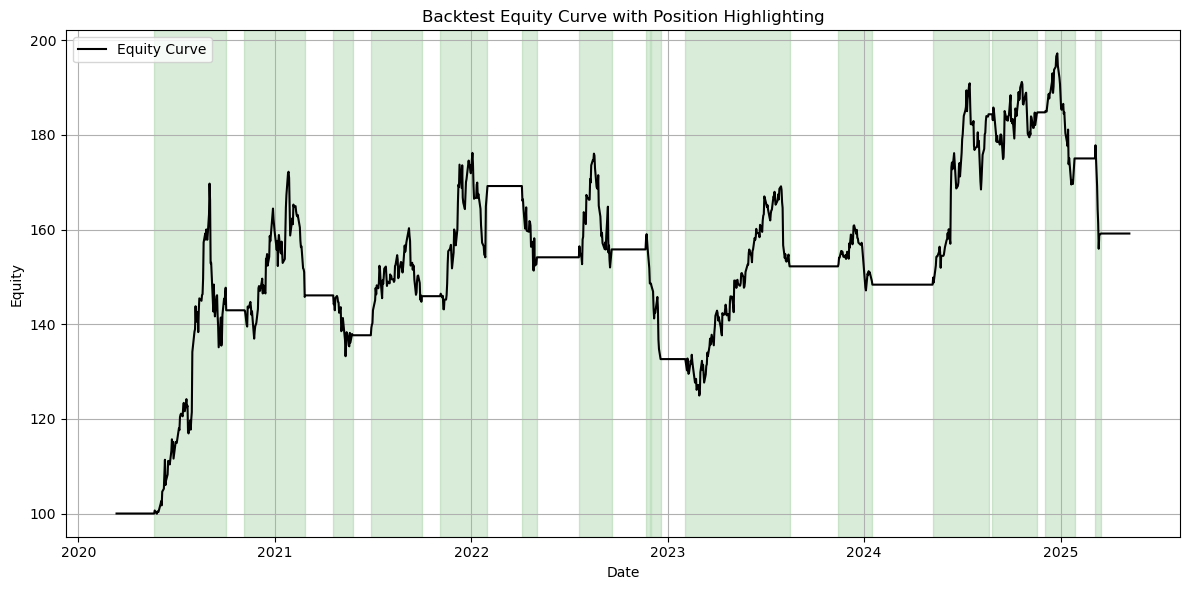

{'Total Trades': 15, 'Winning Trades': 8, 'Losing Trades': 7, 'Win Rate (%)': 53.333333333333336, 'Avg Win (%)': 13.42766109227343, 'Avg Loss (%)': -6.701280912255037, 'Reward/Risk Ratio': 2.0037454433103163, 'Average Duration (days)': 72.93333333333334, 'Max Duration (days)': 194, 'Min Duration (days)': 8, 'Total Return (%)': 60.512322352402194, 'Cumulative Return Multiple': 1.5915277331693845}


In [573]:
# Backtesting Long only SMA

signals_strat = signal_obj2.signals()  

bt = Backtester(data, signals_strat) # testing long SMA strategy
bt.run()
print(bt.get_performance())
print(bt.get_alpha_beta_vs_market(market="SPY"))
bt.plot_equity_curve()
print(analyze_trade_log(bt.get_trade_log()))


[*********************100%***********************]  1 of 1 completed

{'Total Return': -43.13175595134483, 'Annual Return (%)': -10.379112451749107, 'Annual Volatility (%)': 31.815937925832948, 'Sharpe Ratio': -0.1843909544815326, 'Sortino Ratio': -0.250304560704216, 'Max Drawdown (%)': -56.89136717028362, 'Exposure (%)': 99.92295839753467, 'self Alpha': -0.05406967231701879, 'self Beta': -0.15280794038185005}
{'Alpha vs SPY': 0.03604909857682084, 'Beta vs SPY': -0.42500154586957223}


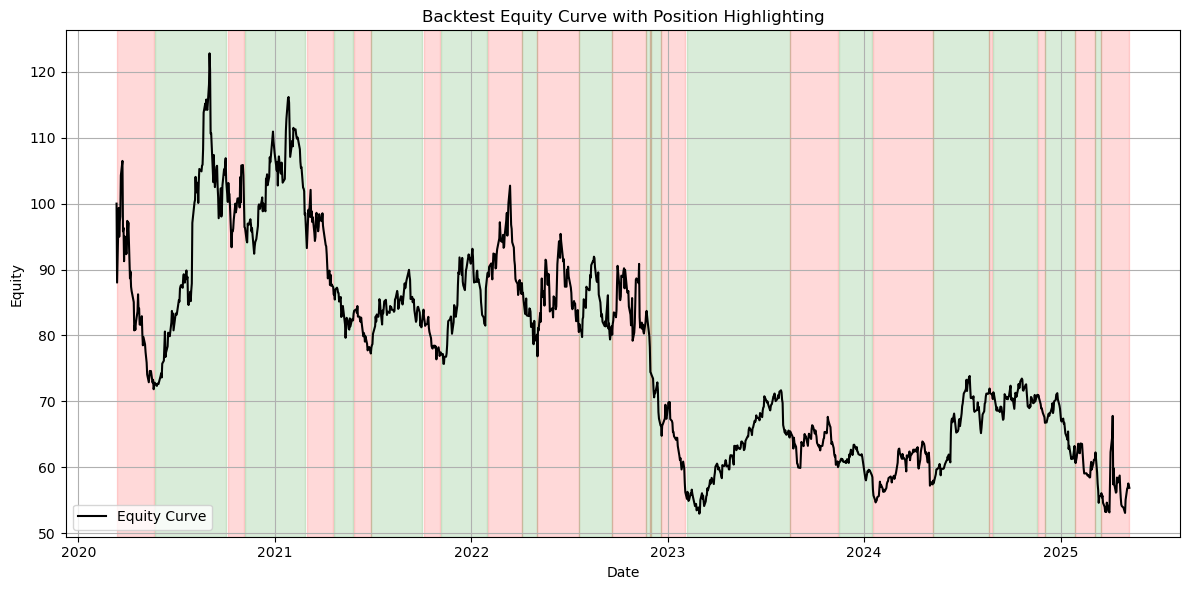

{'Total Trades': 31, 'Winning Trades': 12, 'Losing Trades': 19, 'Win Rate (%)': 38.70967741935484, 'Avg Win (%)': 10.786476074865211, 'Avg Loss (%)': -6.173265406093585, 'Reward/Risk Ratio': 1.7472885685779782, 'Average Duration (days)': 59.516129032258064, 'Max Duration (days)': 191, 'Min Duration (days)': 1, 'Total Return (%)': 12.145670182604427, 'Cumulative Return Multiple': 2.3684800275719664}


In [574]:
# Backtesting Long and short SMA

signals_strat = signal_obj.signals()

bt2 = Backtester(data, signals_strat)
bt2.run()
print(bt2.get_performance())
print(bt2.get_alpha_beta_vs_market(market="SPY"))
bt2.plot_equity_curve()
print(analyze_trade_log(bt2.get_trade_log()))

Simple analysis shows that this strat seems to fail a lot in short trading periods, to fix this we could allow a delay before joining the market. Additionally, all our profits seem to peak and then shoot back down because we were delayed in selling, to solve this we could impliment a basic take profits and stop losses say we make it repeat as something like take 5% and lose 2%, and we then enter the trade again immedietly, this in practice would have transaction fees (slippage) but in demo we dont have to worry, plus some trading apps dont charge these fees. so lets implement that.

In [576]:
#First Real Strategy (after examinig SMA I want to see how this perfoms)
class TP_SL_delayed_SMA_multiStrategy:
    def __init__(self, indicator, stop_loss=0.02, take_profit=0.05, signal_delay=2):
        self.indicator = indicator
        self.data = indicator.data.copy()
        self.stop_loss = stop_loss
        self.take_profit = take_profit
        self.signal_delay = signal_delay
        self.signals_ = pd.DataFrame(index=self.data.index)
        self._computed = False

    def compute(self):
        if self._computed:
            return

        base_signals = self.indicator.signals()['Signal'].values
        delayed_signal = pd.Series(index=self.data.index, data=0)

        count = 0
        prev_signal = 0
        for i in range(1, len(base_signals)):
            raw_signal = base_signals[i]
            if raw_signal == prev_signal:
                count += 1
            else:
                count = 1
                prev_signal = raw_signal

            if count >= self.signal_delay:
                delayed_signal.iloc[i] = raw_signal
            else:
                delayed_signal.iloc[i] = 0

        final_signals = pd.Series(index=self.data.index, data=0)
        entry_price = None
        last_entry_signal = None
        active_position = 0
        cooldown_counter = 0

        for i in range(1, len(base_signals)):
            idx = self.data.index[i]
            price = self.data['Close'].iloc[i]
            delayed_value = delayed_signal.iloc[i]
            signal_today = delayed_value

            if active_position == 0:
                if cooldown_counter == 0 and delayed_value != 0:
                    active_position = delayed_value
                    entry_price = price
                    signal_today = active_position
                    last_entry_signal = delayed_value
            else:
                price_change = (price - entry_price) / entry_price
                if active_position == -1:
                    price_change = -price_change

                if price_change.item() >= self.take_profit:
                    signal_today = 0
                    active_position = 0
                    entry_price = None
                    cooldown_counter = 0
                elif price_change.item() <= -self.stop_loss:
                    signal_today = 0
                    active_position = 0
                    entry_price = None
                    cooldown_counter = self.signal_delay
                elif delayed_value == 0:
                    active_position = 0
                    entry_price = None
                    signal_today = 0
                    cooldown_counter = 0

            if cooldown_counter > 0:
                cooldown_counter -= 1

            final_signals.iloc[i] = signal_today

        self.signals_ = final_signals.to_frame(name='Signal')
        self._computed = True

    def signals(self):
        self.compute()
        return self.signals_


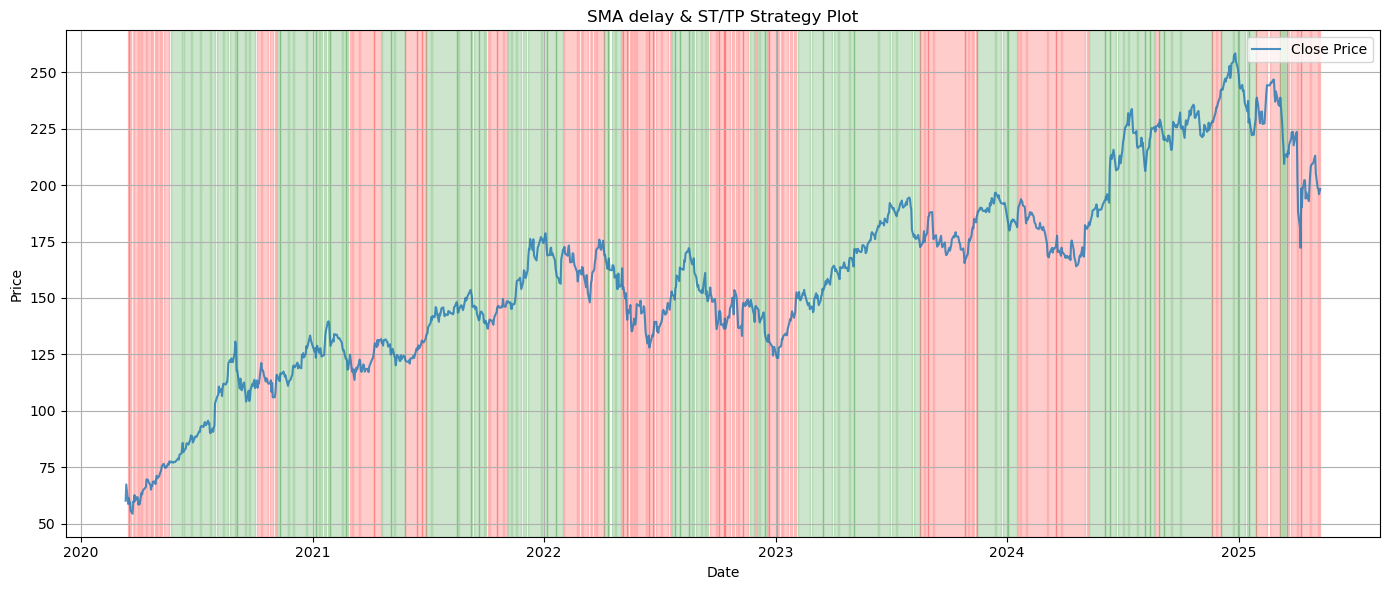

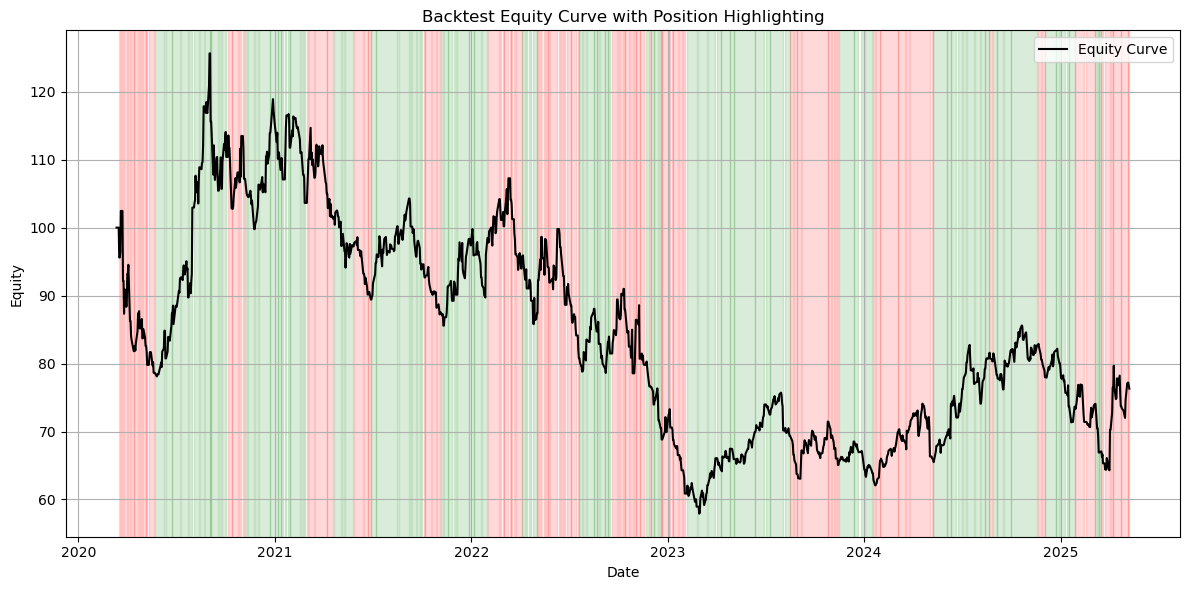

[*********************100%***********************]  1 of 1 completed

{'Total Return': -23.701983331391546, 'Annual Return (%)': -5.1165311514541845, 'Annual Volatility (%)': 27.73664674212593, 'Sharpe Ratio': -0.05055311264831389, 'Sortino Ratio': -0.06735704819429691, 'Max Drawdown (%)': -53.910644451426414, 'Exposure (%)': 84.89984591679507, 'self Alpha': -0.048002717438672855, 'self Beta': -0.00971953685199867}
{'Total Trades': 187, 'Winning Trades': 65, 'Losing Trades': 122, 'Win Rate (%)': 34.75935828877005, 'Avg Win (%)': 5.719681349820847, 'Avg Loss (%)': -3.0936680366244778, 'Reward/Risk Ratio': 1.8488348724259474, 'Average Duration (days)': 8.529411764705882, 'Max Duration (days)': 49, 'Min Duration (days)': 1, 'Total Return (%)': -5.648212729831142, 'Cumulative Return Multiple': 2.4979094901137096}
{'Alpha vs SPY': 0.023790523519073375, 'Beta vs SPY': -0.16940861831816464}


In [577]:
sma = SMAIndicator(data, short_window=20, long_window=50)

strategy = TP_SL_delayed_SMA_multiStrategy(
    indicator=sma,
    stop_loss=0.02,
    take_profit=0.05,
    signal_delay=2
)

#signals = strategy.signals()
#print(signals['Signal'].value_counts())



signal_obj3=strategy

plotter = Plotter(data)
plotter.plot_signals(signal_obj3, title="SMA delay & ST/TP Strategy Plot", highlight = True, plot_indicators = True)


signals=strategy.signals()

bt = Backtester(data, signals)
bt.run()
bt.plot_equity_curve()
print(bt.get_performance())
print(analyze_trade_log(bt.get_trade_log()))
print(bt.get_alpha_beta_vs_market(market="SPY"))



In [578]:
signals = strategy.signals()
print(signals['Signal'].value_counts())

Signal
 1    648
-1    455
 0    195
Name: count, dtype: int64


In [579]:
bt.get_trade_log()

,Type,Entry Date,Exit Date,Entry Price,Exit Price,PnL (%)
0,Short,2020-03-16,2020-03-17,58.702309,61.283455,-4.397010
1,Short,2020-03-18,2020-03-20,59.783241,55.558880,7.066130
2,Short,2020-03-23,2020-03-24,54.378582,59.834141,-10.032551
3,Short,2020-03-25,2020-04-01,59.504528,58.387238,1.877656
4,Short,2020-04-02,2020-04-06,59.361530,63.612549,-7.161235
...,...,...,...,...,...,...
182,Short,2025-03-24,2025-04-03,220.440918,202.923904,7.946353
183,Short,2025-04-04,2025-04-08,188.133301,172.194199,8.472239
184,Short,2025-04-09,2025-04-23,198.589584,204.332062,-2.891631
185,Short,2025-04-24,2025-05-06,208.097107,198.250015,4.731970


PnL % Summary:
count    187.000000
mean       0.596996
std        4.630328
min       -9.429988
25%       -3.199412
50%        0.998508
75%        4.392634
max       14.733056
dtype: float64


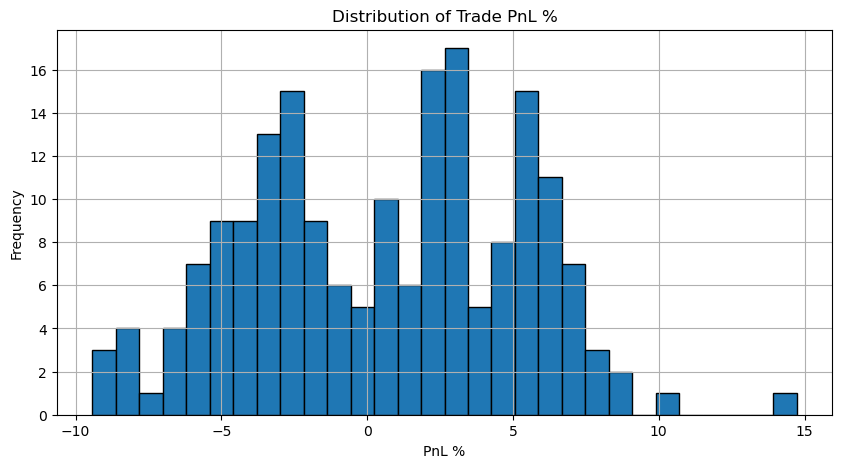

In [580]:
# Get the trade log
trade_log = bt.get_trade_log()

# Compute PnL %
pnl_series = (trade_log['Exit Price'] - trade_log['Entry Price']) / trade_log['Entry Price'] * 100

# Summary stats
print("PnL % Summary:")
print(pnl_series.describe())

# Optional: Plot the histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(pnl_series, bins=30, edgecolor='black')
plt.title('Distribution of Trade PnL %')
plt.xlabel('PnL %')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


In [581]:
#lets look at this again but without shorting
#First Real Strategy (after examinig SMA I want to see how this perfoms)
class TP_SL_delayed_SMA_Long_Strategy:
    def __init__(self, indicator, stop_loss=0.02, take_profit=0.05, signal_delay=2):
        self.indicator = indicator
        self.data = indicator.data.copy()
        self.stop_loss = stop_loss
        self.take_profit = take_profit
        self.signal_delay = signal_delay
        self.signals_ = pd.DataFrame(index=self.data.index)
        self._computed = False

    def compute(self):
        if self._computed:
            return

        base_signals = self.indicator.signals()['Signal'].values
        delayed_signal = pd.Series(index=self.data.index, data=0)

        count = 0
        prev_signal = 0
        for i in range(1, len(base_signals)):
            raw_signal = base_signals[i]
            if raw_signal == prev_signal:
                count += 1
            else:
                count = 1
                prev_signal = raw_signal

            if count >= self.signal_delay:
                delayed_signal.iloc[i] = raw_signal
            else:
                delayed_signal.iloc[i] = 0

        final_signals = pd.Series(index=self.data.index, data=0)
        entry_price = None
        last_entry_signal = None
        active_position = 0
        cooldown_counter = 0

        for i in range(1, len(base_signals)):
            idx = self.data.index[i]
            price = self.data['Close'].iloc[i]
            delayed_value = delayed_signal.iloc[i]
            signal_today = delayed_value

            if active_position == 0:
                if cooldown_counter == 0 and delayed_value != 0:
                    active_position = delayed_value
                    entry_price = price
                    signal_today = active_position
                    last_entry_signal = delayed_value
            else:
                price_change = (price - entry_price) / entry_price
                if active_position == -1:
                    price_change = -price_change

                if price_change.item() >= self.take_profit:
                    signal_today = 0
                    active_position = 0
                    entry_price = None
                    cooldown_counter = 0
                elif price_change.item() <= -self.stop_loss:
                    signal_today = 0
                    active_position = 0
                    entry_price = None
                    cooldown_counter = self.signal_delay
                elif delayed_value == 0:
                    active_position = 0
                    entry_price = None
                    signal_today = 0
                    cooldown_counter = 0

            if cooldown_counter > 0:
                cooldown_counter -= 1

            final_signals.iloc[i] = signal_today

        self.signals_ = final_signals.to_frame(name='Signal')
        self._computed = True

    def signals(self):
        self.compute()
        return self.signals_


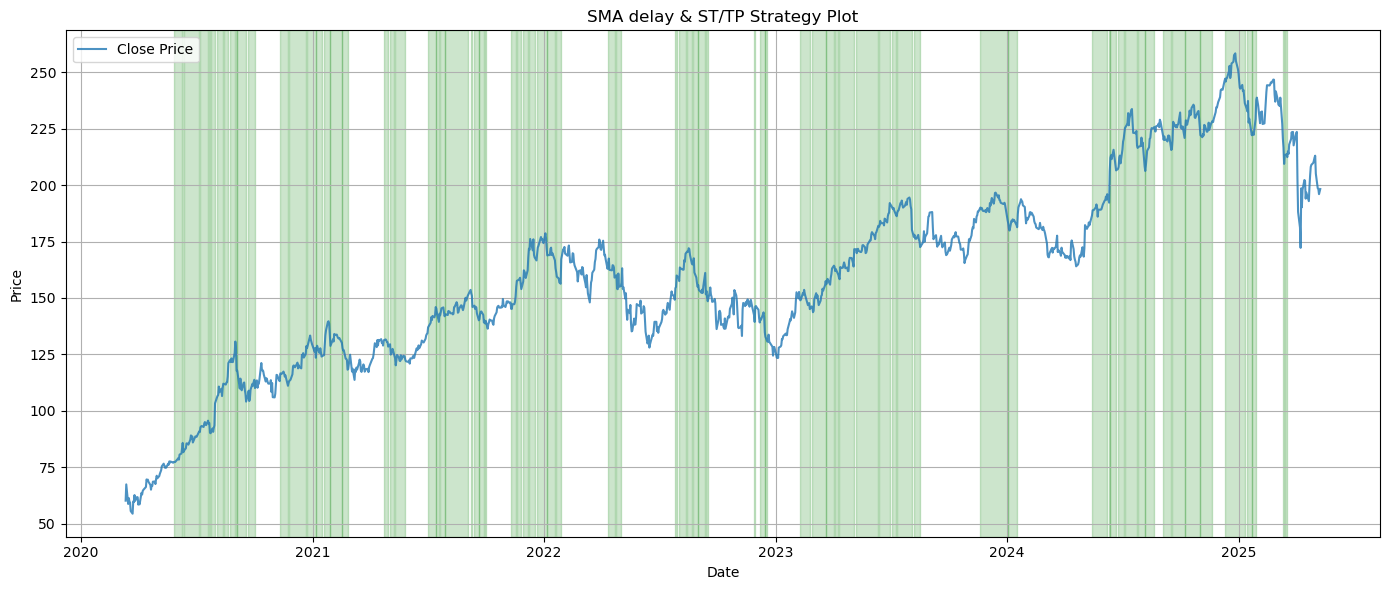

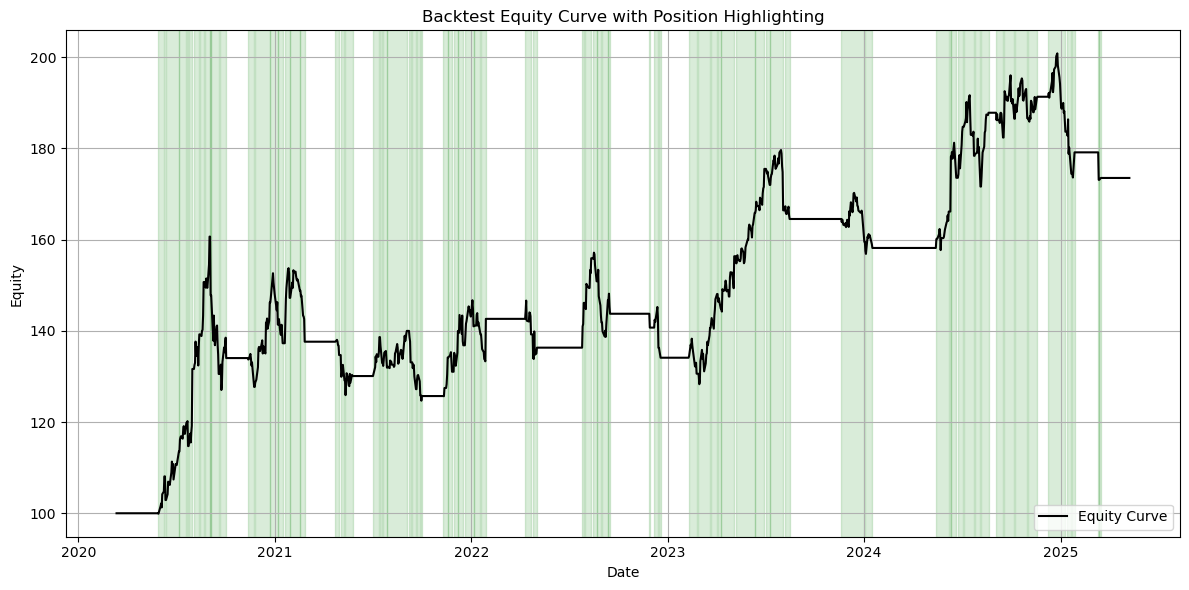

[*********************100%***********************]  1 of 1 completed

{'Total Return': 73.5065631567712, 'Annual Return (%)': 11.291487745981943, 'Annual Volatility (%)': 19.155541778958334, 'Sharpe Ratio': 0.6540445817578037, 'Sortino Ratio': 0.6611367315489267, 'Max Drawdown (%)': -22.388329569281385, 'Exposure (%)': 47.996918335901384, 'self Alpha': -0.005136535698229985, 'self Beta': 0.36280503697108474}
{'Total Trades': 76, 'Winning Trades': 35, 'Losing Trades': 41, 'Win Rate (%)': 46.05263157894737, 'Avg Win (%)': 5.813096810972464, 'Avg Loss (%)': -3.354360622021004, 'Reward/Risk Ratio': 1.732996974985376, 'Average Duration (days)': 11.789473684210526, 'Max Duration (days)': 43, 'Min Duration (days)': 1, 'Total Return (%)': 65.92960288117513, 'Cumulative Return Multiple': 1.7350656315677147}
{'Alpha vs SPY': 0.06107881634435987, 'Beta vs SPY': 0.33436797161592313}


In [582]:
smastrategy = SMACrossoverStrategy(signal_obj)

strategy2 = TP_SL_delayed_SMA_multiStrategy(
    indicator=smastrategy,
    stop_loss=0.02,
    take_profit=0.05,
    signal_delay=5
)

#signals = strategy.signals()
#print(signals['Signal'].value_counts())


plotter = Plotter(data)
plotter.plot_signals(strategy2, title="SMA delay & ST/TP Strategy Plot", highlight = True, plot_indicators = True)


bt = Backtester(data, strategy2.signals())
bt.run()
bt.plot_equity_curve()
print(bt.get_performance())
print(analyze_trade_log(bt.get_trade_log()))
print(bt.get_alpha_beta_vs_market(market="SPY"))


PnL % Summary:
count    76.000000
mean      0.867495
std       5.377911
min     -11.673265
25%      -3.172201
50%      -0.955924
75%       5.880804
max      14.733056
dtype: float64


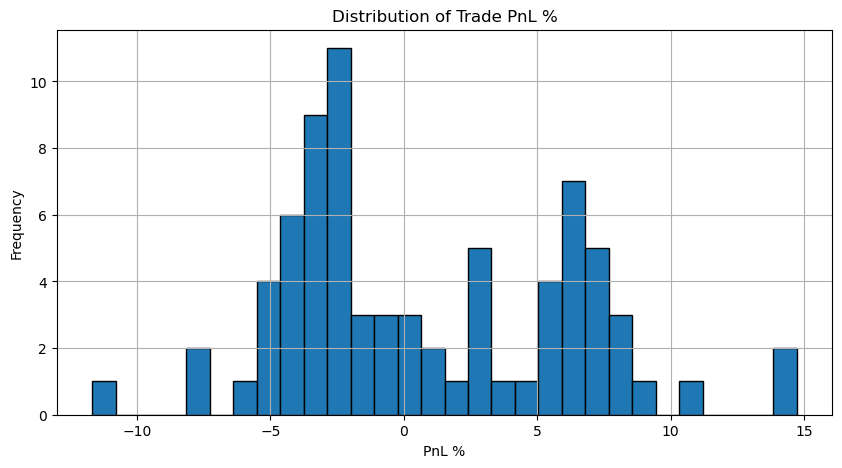

In [583]:
# Get the trade log
trade_log = bt.get_trade_log()

# Compute PnL %
pnl_series = (trade_log['Exit Price'] - trade_log['Entry Price']) / trade_log['Entry Price'] * 100

# Summary stats
print("PnL % Summary:")
print(pnl_series.describe())

# Optional: Plot the histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(pnl_series, bins=30, edgecolor='black')
plt.title('Distribution of Trade PnL %')
plt.xlabel('PnL %')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


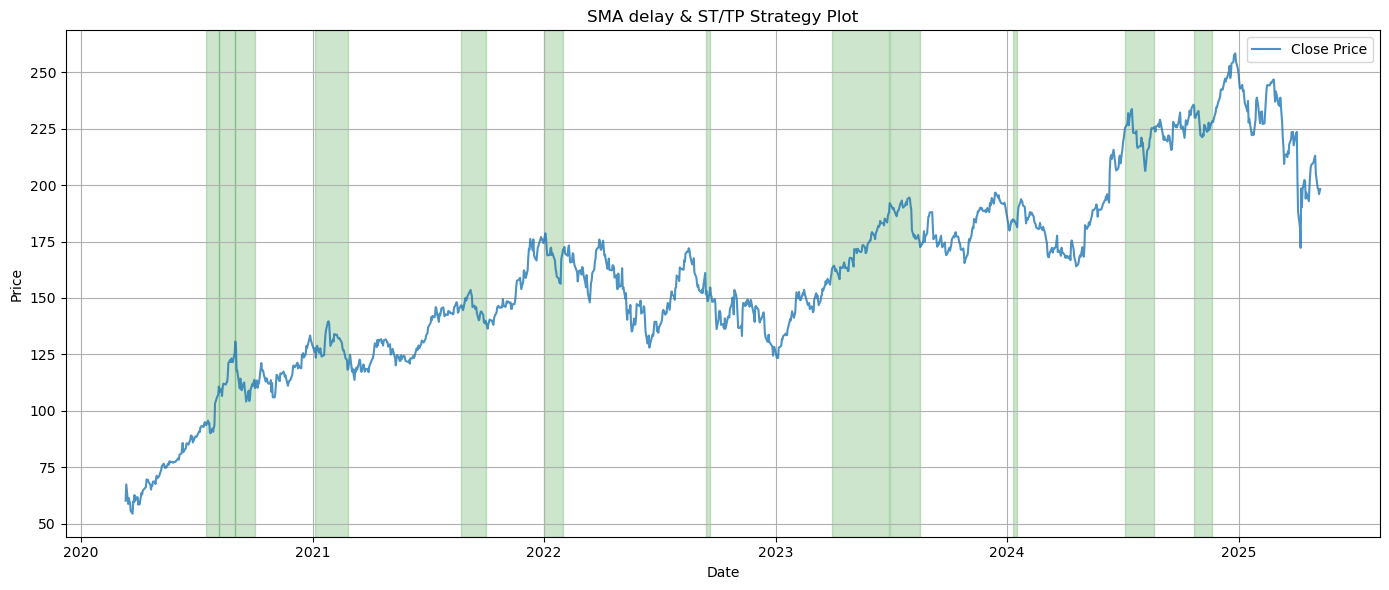

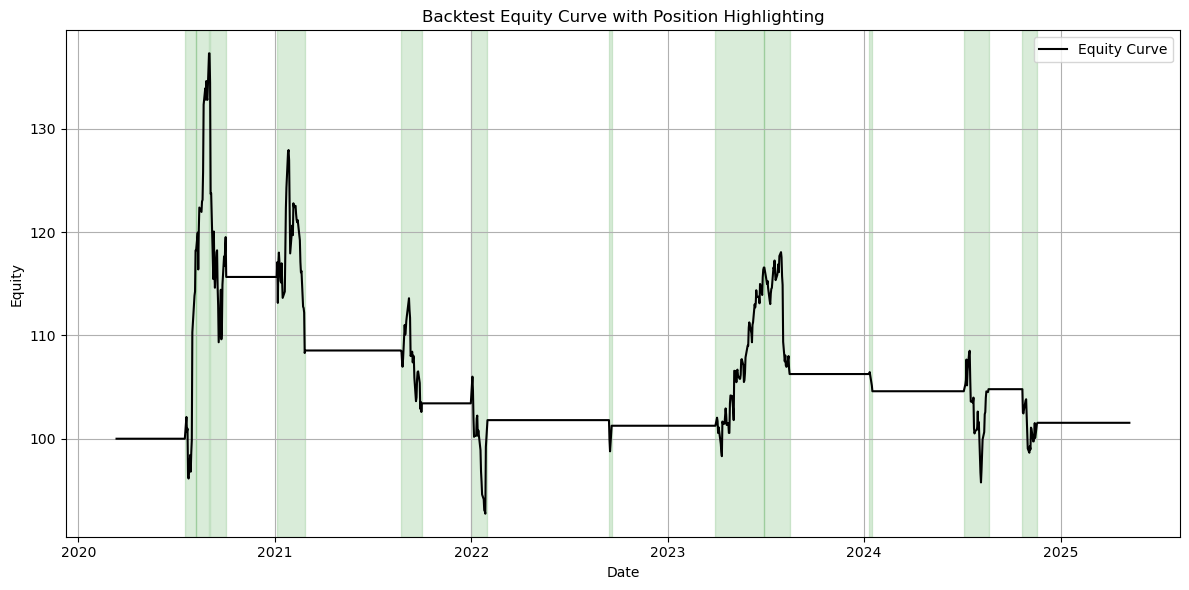

[*********************100%***********************]  1 of 1 completed

{'Total Return': 1.5419060673962832, 'Annual Return (%)': 0.2975103709093485, 'Annual Volatility (%)': 13.921813828393104, 'Sharpe Ratio': 0.09068359743188542, 'Sortino Ratio': 0.060906167113973675, 'Max Drawdown (%)': -32.46721792627588, 'Exposure (%)': 22.18798151001541, 'self Alpha': -0.05946942697281683, 'self Beta': 0.19190952193313704}
{'Total Trades': 12, 'Winning Trades': 4, 'Losing Trades': 8, 'Win Rate (%)': 33.33333333333333, 'Avg Win (%)': 12.42555988095344, 'Avg Loss (%)': -5.283985659044873, 'Reward/Risk Ratio': 2.3515506442913905, 'Average Duration (days)': 35.0, 'Max Duration (days)': 90, 'Min Duration (days)': 5, 'Total Return (%)': 7.430354251454774, 'Cumulative Return Multiple': 1.0154190606739624}
{'Alpha vs SPY': -0.020747476523946824, 'Beta vs SPY': 0.15439394635303122}


In [584]:
smastrategy = SMACrossoverStrategy(signal_obj)

strategy3 = TP_SL_delayed_SMA_multiStrategy(
    indicator=smastrategy,
    stop_loss=0.5,
    take_profit=0.15,
    signal_delay=40
)


plotter = Plotter(data)
plotter.plot_signals(strategy3, title="SMA delay & ST/TP Strategy Plot", highlight = True, plot_indicators = True)


bt = Backtester(data, strategy3.signals())
bt.run()
bt.plot_equity_curve()
print(bt.get_performance())
print(analyze_trade_log(bt.get_trade_log()))
print(bt.get_alpha_beta_vs_market(market="SPY"))


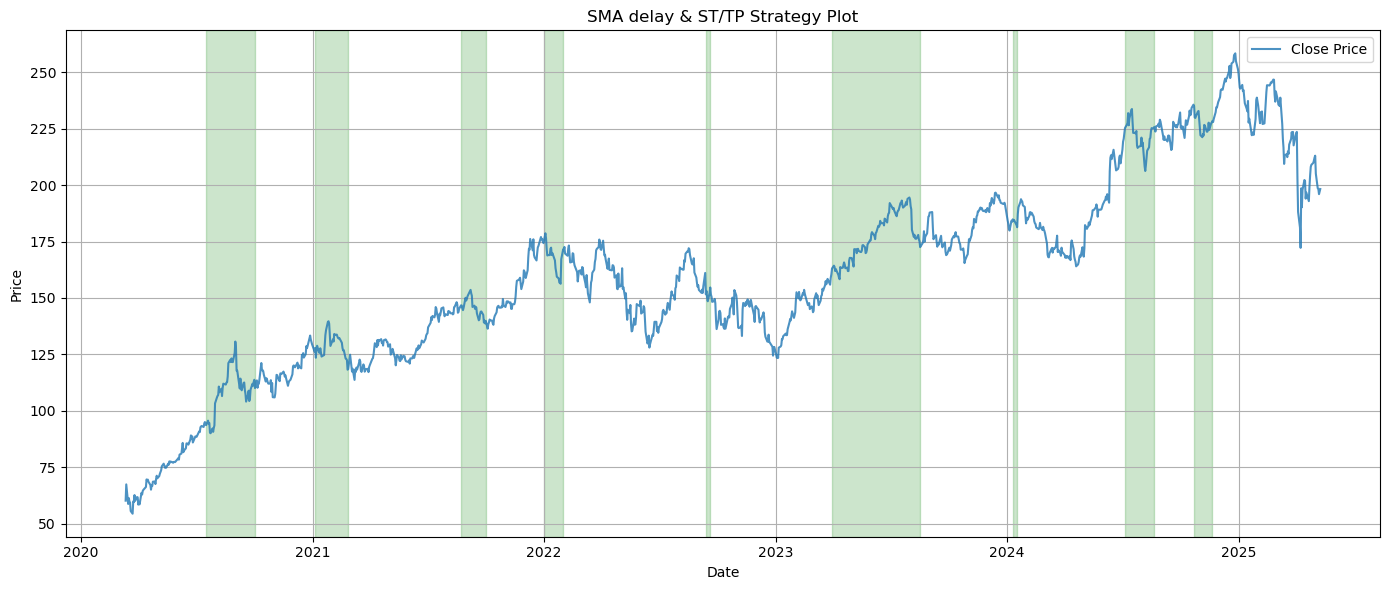

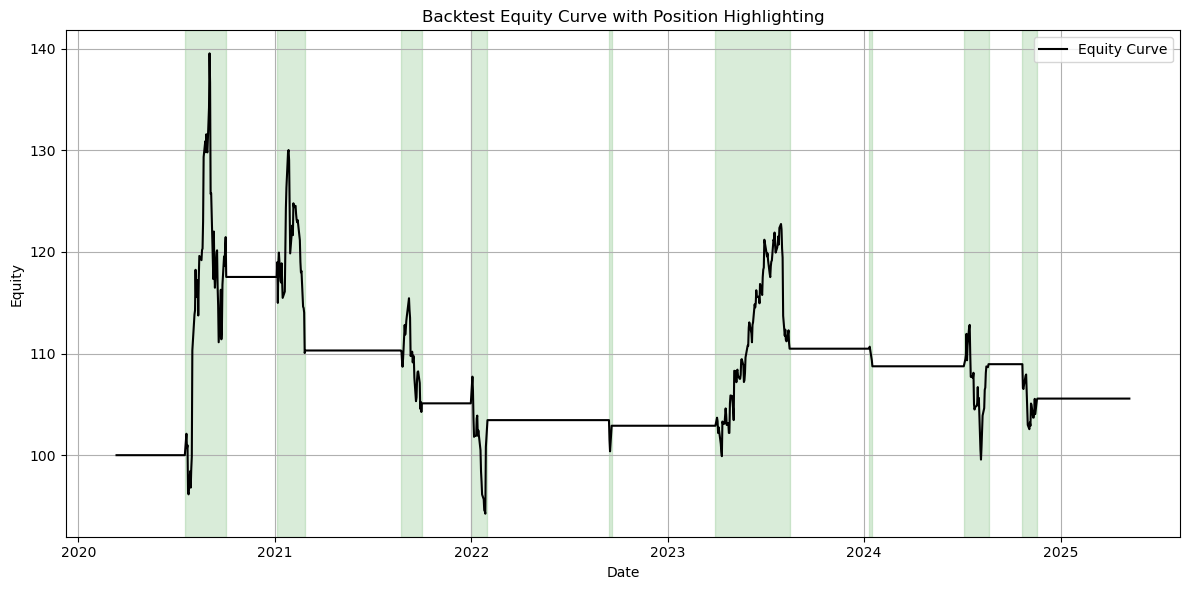

[*********************100%***********************]  1 of 1 completed

{'Total Return': 5.569873317896551, 'Annual Return (%)': 1.0578767972610148, 'Annual Volatility (%)': 14.10427973715596, 'Sharpe Ratio': 0.14484498654564615, 'Sortino Ratio': 0.09872427806567224, 'Max Drawdown (%)': -32.467217926275985, 'Exposure (%)': 22.4191063174114, 'self Alpha': -0.05348963037041796, 'self Beta': 0.19690012180032562}
{'Total Trades': 9, 'Winning Trades': 3, 'Losing Trades': 6, 'Win Rate (%)': 33.33333333333333, 'Avg Win (%)': 8.367100580368133, 'Avg Loss (%)': -2.9424151665746727, 'Reward/Risk Ratio': 2.8436165893300673, 'Average Duration (days)': 47.0, 'Max Duration (days)': 138, 'Min Duration (days)': 5, 'Total Return (%)': 7.446810741656361, 'Cumulative Return Multiple': 1.0556987331789676}
{'Alpha vs SPY': -0.013408840782171215, 'Beta vs SPY': 0.1571700975105614}


In [585]:
smastrategy = SMACrossoverStrategy(signal_obj)

strategy3 = TP_SL_delayed_SMA_multiStrategy(
    indicator=smastrategy,
    stop_loss=1,
    take_profit=1,
    signal_delay=40
)


plotter = Plotter(data)
plotter.plot_signals(strategy3, title="SMA delay & ST/TP Strategy Plot", highlight = True, plot_indicators = True)


bt = Backtester(data, strategy3.signals())
bt.run()
bt.plot_equity_curve()
print(bt.get_performance())
print(analyze_trade_log(bt.get_trade_log()))
print(bt.get_alpha_beta_vs_market(market="SPY"))


In [586]:
 day to day p/l or take loss from max profit since opened

SyntaxError: invalid syntax (3933013506.py, line 1)

In [ ]:
1) scanner
1) indicators
3)strategies
4) portfolio
5) optimizar en vivo

 test and practice
start small investment

In [ ]:
print(bt.get_trade_log())